<a href="https://colab.research.google.com/github/ajs-sw/2026_tues_bigdatacomputing_class/blob/main/20230579_%EC%95%88%EC%A0%95%EC%88%98_%EC%A4%91%EA%B0%84%EA%B3%A0%EC%82%AC_%ED%94%84%EB%A1%9C%EA%B7%B8%EB%9E%98%EB%B0%8D_%EA%B3%BC%EC%A0%9C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# [중간고사 실기 과제] 시계열 기상 데이터 통합 분석 파이프라인 구축
1. 과제 개요

  - 본 과제는 실무 데이터 분석 프로세스를 경험하기 위해 웹상의 기상 데이터를 수집하고, 이를 기계학습 모델링이 가능한 형태의 '깨끗한 데이터'로 가공하는 통합 분석 파이프라인을 개별 함수 단위로 구현하기.

2. 데이터 소스

  - URL: https://github.com/dongupak/DataML/raw/main/csv/weather.csv

  - 주요 컬럼: 지점, 일시, 평균기온, 최대풍속, 평균풍속

3. 핵심 요구 사항 (평가 기준)

  - 모듈화 설계:
    - 모든 기능은 독립적인 함수로 작성되어야 하고,
    - main() 함수에서 제어되어야 함.

  - 데이터 정규화 (Min-Max Scaling):
    - 특정 수치 데이터를 0과 1 사이로 변환하는 함수를 포함해야 함.

  - 시계열 핸들링:
    - 날짜 변환, 인덱스 설정 및 7일 이동 평균 추세선을 생성해야 함.

  - 데이터 재구조화:
    - pivot_table과 groupby를 활용하여 다차원적인 통계량을 산출해야 함.

  - 엑셀 내보내기 (To Excel):
    - 분석 결과인 전처리 데이터, 계절별 통계, 연도별 피벗 테이블을 하나의 엑셀 파일(weather_analysis_report.xlsx)의 별도 시트에 각각 저장해야 함.

  - 다음과 같은 데이터분석 그래프을 생성해야 함.
  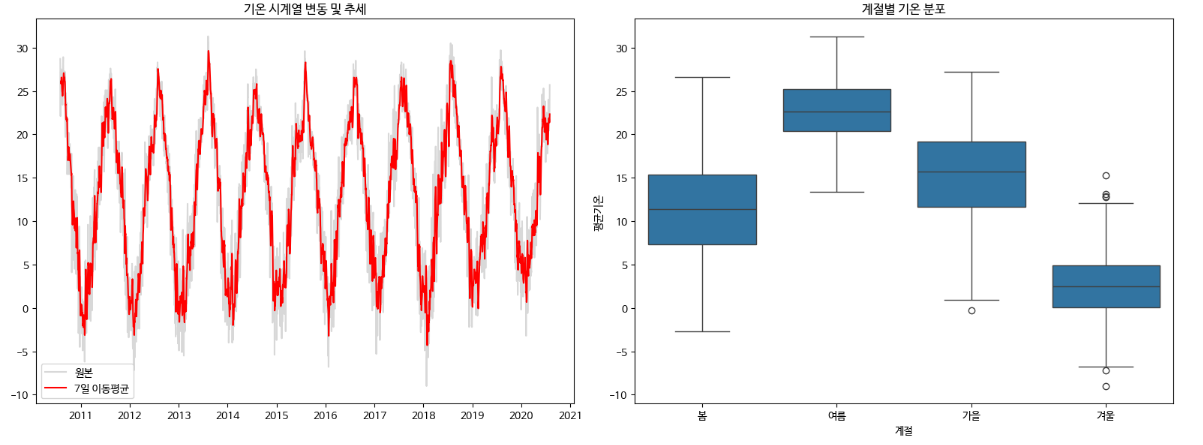

  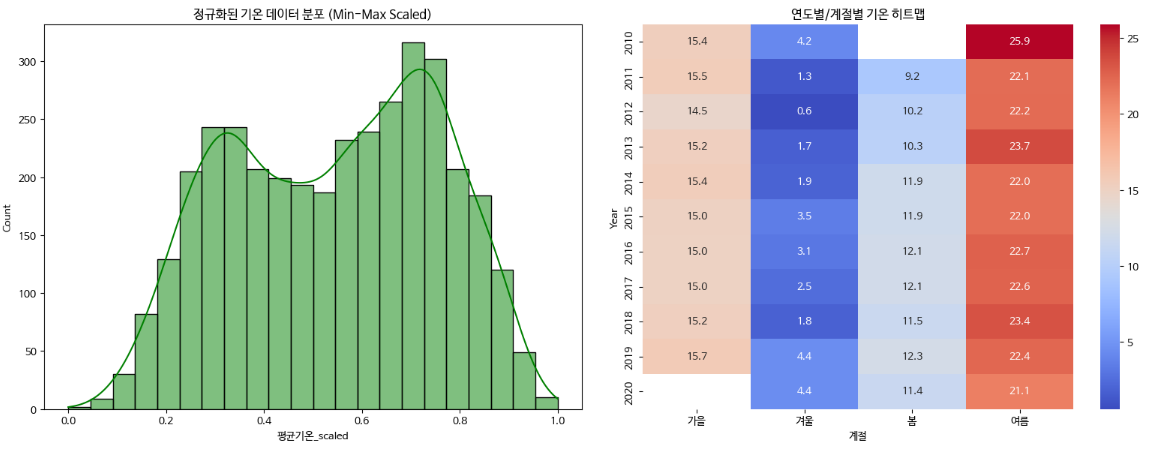



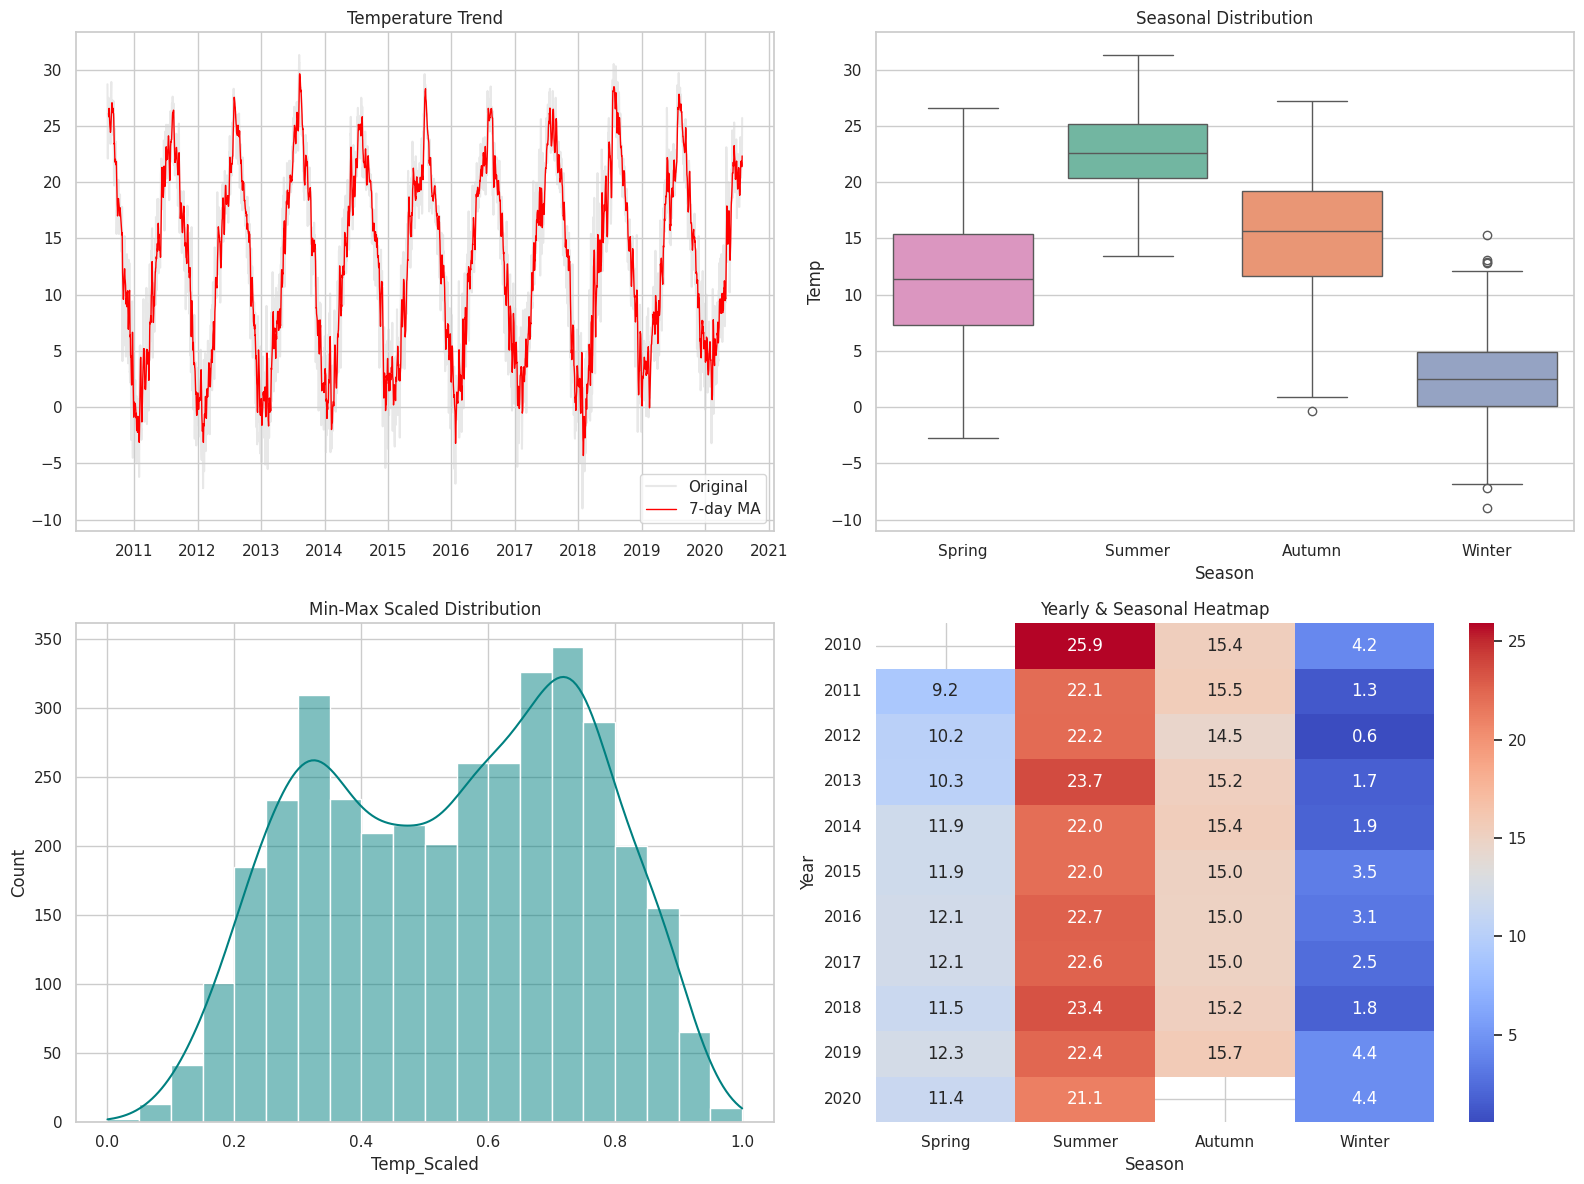

분석 완료! 파일이 생성되었습니다: weather_analysis_report.xlsx


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

# 1. 데이터 로드 함수
def load_data(url):
    # 컬럼명을 직접 지정하지 않고 먼저 로드합니다.
    df = pd.read_csv(url, encoding='cp949')

    # [수정] 한글 컬럼명을 영문으로 매핑 (에러 방지)
    # 데이터에 존재하는 컬럼만 찾아서 이름을 바꿉니다.
    rename_map = {
        '일시': 'Date',
        '평균기온': 'Temp',
        '최대풍속': 'Max_Wind',
        '평균풍속': 'Avg_Wind',
        '지점': 'Station'
    }
    df = df.rename(columns=rename_map)
    return df

# 2. 데이터 전처리 함수
def preprocess_data(df):
    # 'Date'와 'Temp' 컬럼이 있는지 확인 후 처리
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.dropna(subset=['Temp']).copy()

    def get_season_en(month):
        if month in [3, 4, 5]: return 'Spring'
        elif month in [6, 7, 8]: return 'Summer'
        elif month in [9, 10, 11]: return 'Autumn'
        else: return 'Winter'

    df['Year'] = df['Date'].dt.year
    df['Season'] = df['Date'].dt.month.apply(get_season_en)
    return df

# 3. 데이터 정규화 함수
def normalize_data(df):
    scaler = MinMaxScaler()
    df['Temp_Scaled'] = scaler.fit_transform(df[['Temp']])
    return df

# 4. 시계열 핸들링
def feature_engineering(df):
    df_sorted = df.sort_values('Date').copy()
    df_sorted['MA7'] = df_sorted['Temp'].rolling(window=7).mean()
    return df_sorted

# 5. 데이터 재구조화
def analyze_data(df):
    season_stats = df.groupby('Season')['Temp'].describe()
    pivot_table = df.pivot_table(values='Temp', index='Year', columns='Season', aggfunc='mean')

    order = ['Spring', 'Summer', 'Autumn', 'Winter']
    pivot_table = pivot_table.reindex(columns=[s for s in order if s in pivot_table.columns])

    return season_stats, pivot_table

# 6. 시각화 함수
def visualize(df, pivot_table):
    plt.rcParams.update(plt.rcParamsDefault)
    sns.set_theme(style="whitegrid")

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    # (1) 기온 시계열 변동
    axes[0, 0].plot(df['Date'], df['Temp'], color='lightgrey', label='Original', alpha=0.5)
    axes[0, 0].plot(df['Date'], df['MA7'], color='red', label='7-day MA', linewidth=1)
    axes[0, 0].set_title("Temperature Trend")
    axes[0, 0].legend()

    # (2) 계절별 기온 분포
    sns.boxplot(data=df, x='Season', y='Temp', hue='Season',
                order=['Spring', 'Summer', 'Autumn', 'Winter'],
                ax=axes[0, 1], palette='Set2', legend=False)
    axes[0, 1].set_title("Seasonal Distribution")

    # (3) 정규화된 분포
    sns.histplot(df['Temp_Scaled'], bins=20, kde=True, color='teal', ax=axes[1, 0])
    axes[1, 0].set_title("Min-Max Scaled Distribution")

    # (4) 히트맵
    sns.heatmap(pivot_table, annot=True, fmt=".1f", cmap="coolwarm", ax=axes[1, 1])
    axes[1, 1].set_title("Yearly & Seasonal Heatmap")

    plt.tight_layout()
    plt.show()

# 7. 엑셀 내보내기
def save_to_excel(df, season_stats, pivot_table, filename):
    with pd.ExcelWriter(filename, engine='openpyxl') as writer:
        df.to_excel(writer, sheet_name='Preprocessed_Data', index=False)
        season_stats.to_excel(writer, sheet_name='Seasonal_Stats')
        pivot_table.to_excel(writer, sheet_name='Yearly_Pivot')

# 8. 메인 제어 함수
def main():
    URL = "https://github.com/dongupak/DataML/raw/main/csv/weather.csv"
    REPORT_NAME = "weather_analysis_report.xlsx"

    try:
        df = load_data(URL)
        df = preprocess_data(df)
        df = normalize_data(df)
        df = feature_engineering(df)
        stats, pivot = analyze_data(df)

        visualize(df, pivot)
        save_to_excel(df, stats, pivot, REPORT_NAME)
        print(f"분석 완료! 파일이 생성되었습니다: {REPORT_NAME}")

    except Exception as e:
        print(f"실행 중 오류 발생: {e}")

if __name__ == "__main__":
    main()